In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

from lightgbm import LGBMClassifier

RANDOM_STATE = 42

## 2. Load the original dataset

Change `DATA_PATH` if your CSV is stored somewhere else.

The original notebook used `/content/application_train.csv`.

In [2]:
DATA_PATH = "/content/application_train.csv"

if not os.path.exists(DATA_PATH):
    # Useful when running locally and the CSV is next to the notebook.
    local_path = "application_train.csv"
    if os.path.exists(local_path):
        DATA_PATH = local_path

dataset = pd.read_csv(DATA_PATH)

print("Dataset shape:", dataset.shape)
display(dataset.head())

Dataset shape: (15523, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Basic inspection
print("Data types:")
display(dataset.dtypes.value_counts())

print("\nDuplicate rows:", dataset.duplicated().sum())

print("\nTarget distribution:")
display(dataset["TARGET"].value_counts())

print("\nTarget percentage:")
display((dataset["TARGET"].value_counts(normalize=True) * 100).round(2))

Data types:


,count
float64,95
object,16
int64,11



Duplicate rows: 0

Target distribution:


,count
TARGET,
0,14306
1,1217



Target percentage:


,proportion
TARGET,
0,92.16
1,7.84


## 3. Check for unexpected row loss

The original notebook appeared to move from roughly 27,166 rows to roughly 25,726 rows.

This version does **not** silently drop rows. We first measure duplicates and missingness, and any explicit row removal is recorded.

In [4]:
print("Rows at load:", len(dataset))
print("Duplicate rows:", dataset.duplicated().sum())
print("\nRows currently:", len(dataset))

Rows at load: 15523
Duplicate rows: 0

Rows currently: 15523


## 4. Feature engineering

These transformations are row-wise and therefore do not learn statistics from the dataset. They can safely be created before the train/validation/test split.

We retain the useful features from the original notebook and fix the missing-value indicator bug.

In [5]:
df = dataset.copy()


df["OWN_CAR_AGE_MISSING"] = df["OWN_CAR_AGE"].isna().astype("int8")


# Home Credit DAYS_EMPLOYED sentinel
# 365243 is used as an anomalous/missing employment value.
# Convert it to NaN so the imputer can handle it.

if "DAYS_EMPLOYED" in df.columns:
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)


# Feature engineering


def safe_ratio(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator

if {"AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"}.issubset(df.columns):
    df["INCOME_PER_PERSON"] = safe_ratio(
        df["AMT_INCOME_TOTAL"],
        df["CNT_FAM_MEMBERS"]
    )

if {"AMT_ANNUITY", "AMT_INCOME_TOTAL"}.issubset(df.columns):
    df["ANNUITY_INCOME_RATIO"] = safe_ratio(
        df["AMT_ANNUITY"],
        df["AMT_INCOME_TOTAL"]
    )

if {"AMT_CREDIT", "AMT_INCOME_TOTAL"}.issubset(df.columns):
    df["CREDIT_INCOME_RATIO"] = safe_ratio(
        df["AMT_CREDIT"],
        df["AMT_INCOME_TOTAL"]
    )

if {"AMT_GOODS_PRICE", "AMT_CREDIT"}.issubset(df.columns):
    df["GOODS_CREDIT_RATIO"] = safe_ratio(
        df["AMT_GOODS_PRICE"],
        df["AMT_CREDIT"]
    )

if "DAYS_BIRTH" in df.columns:
    df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.0

if "DAYS_EMPLOYED" in df.columns:
    df["YEARS_EMPLOYED"] = -df["DAYS_EMPLOYED"] / 365.0

print("Shape after row-wise feature engineering:", df.shape)
display(df[[
    c for c in [
        "OWN_CAR_AGE_MISSING",
        "INCOME_PER_PERSON",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_INCOME_RATIO",
        "GOODS_CREDIT_RATIO",
        "AGE_YEARS",
        "YEARS_EMPLOYED"
    ] if c in df.columns
]].head())

Shape after row-wise feature engineering: (15523, 129)


,OWN_CAR_AGE_MISSING,INCOME_PER_PERSON,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,GOODS_CREDIT_RATIO,AGE_YEARS,YEARS_EMPLOYED
0,1,202500.0,0.121978,2.007889,0.863262,25.920548,1.745205
1,1,135000.0,0.132217,4.790750,0.873211,45.931507,3.254795
2,0,67500.0,0.100000,2.000000,1.000000,52.180822,0.616438
3,1,67500.0,0.219900,2.316167,0.949845,52.068493,8.326027
4,1,121500.0,0.179963,4.222222,1.000000,54.608219,8.323288


In [6]:
# Verify the fixed missing indicator
print("OWN_CAR_AGE_MISSING value counts:")
display(df["OWN_CAR_AGE_MISSING"].value_counts(dropna=False))

print("Rows after feature engineering:", len(df))

OWN_CAR_AGE_MISSING value counts:


,count
OWN_CAR_AGE_MISSING,
1,10263
0,5260


Rows after feature engineering: 15523


## 5. Missing-value analysis

We do not blindly delete all columns with high missingness.

The clean baseline drops only extremely sparse columns (>= 80% missing) and retains columns below that threshold. Missingness indicators are added for numerical columns with meaningful missingness.

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str)
}).sort_values("missing_pct", ascending=False)

display(missing_summary.head(30))

,missing_count,missing_pct,dtype
COMMONAREA_MODE,10862,69.973588,float64
COMMONAREA_MEDI,10862,69.973588,float64
COMMONAREA_AVG,10862,69.973588,float64
NONLIVINGAPARTMENTS_MODE,10772,69.393803,float64
NONLIVINGAPARTMENTS_AVG,10772,69.393803,float64
NONLIVINGAPARTMENTS_MEDI,10772,69.393803,float64
FONDKAPREMONT_MODE,10640,68.543452,object
LIVINGAPARTMENTS_MEDI,10622,68.427495,float64
LIVINGAPARTMENTS_AVG,10622,68.427495,float64
LIVINGAPARTMENTS_MODE,10622,68.427495,float64


In [8]:
HIGH_MISSING_THRESHOLD = 80.0

high_missing_cols = missing_summary.index[
    missing_summary["missing_pct"] >= HIGH_MISSING_THRESHOLD
].tolist()

print(f"Columns with >= {HIGH_MISSING_THRESHOLD}% missing:", len(high_missing_cols))

if high_missing_cols:
    display(missing_summary.loc[high_missing_cols])

# Drop only extremely sparse columns for the initial baseline.
# This is intentionally conservative; columns between 50% and 80%
# missing are retained.
df = df.drop(columns=high_missing_cols, errors="ignore")

print("Shape after conservative high-missingness removal:", df.shape)

Columns with >= 80.0% missing: 0
Shape after conservative high-missingness removal: (15523, 129)


## 6. Separate target and features

`SK_ID_CURR` is an identifier, not a meaningful predictive measurement, so it is removed.

We do not remove rows.

In [9]:
TARGET = "TARGET"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

# Identifier: remove from the ML feature matrix.
if "SK_ID_CURR" in X.columns:
    X = X.drop(columns=["SK_ID_CURR"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

print("\nTarget percentage:")
display((y.value_counts(normalize=True) * 100).round(2))

X shape: (15523, 127)
y shape: (15523,)

Target distribution:


,count
TARGET,
0,14306
1,1217



Target percentage:


,proportion
TARGET,
0,92.16
1,7.84


## 7. Stratified train / validation / test split

We use:

- 64% training
- 16% validation
- 20% final test

The validation set is used for threshold selection. The final test set remains untouched until final evaluation.

In [10]:
# First split: 80% temporary train, 20% final test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: 20% of the 80% = 16% total validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nClass distribution:")
print("Train:")
display((y_train.value_counts(normalize=True) * 100).round(2))
print("Validation:")
display((y_val.value_counts(normalize=True) * 100).round(2))
print("Test:")
display((y_test.value_counts(normalize=True) * 100).round(2))

Train: (9934, 127)
Validation: (2484, 127)
Test: (3105, 127)

Class distribution:
Train:


,proportion
TARGET,
0,92.16
1,7.84


Validation:


,proportion
TARGET,
0,92.15
1,7.85


Test:


,proportion
TARGET,
0,92.17
1,7.83


## 8. Add missing indicators for numerical features

For some financial/application variables, the fact that a value is missing can itself carry information.

The indicator is deterministic and does not require fitting a statistic, so it can be created separately for each split using the same column list.

In [11]:
# Identify numeric columns from training data only.
numeric_cols_initial = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

# Add indicators for numeric columns with at least 20% missing in training.
MISSING_INDICATOR_THRESHOLD = 0.20

missing_numeric_rates = X_train[numeric_cols_initial].isna().mean()

missing_indicator_cols = missing_numeric_rates[
    missing_numeric_rates >= MISSING_INDICATOR_THRESHOLD
].index.tolist()

print("Numeric columns:", len(numeric_cols_initial))
print(
    f"Missing-indicator columns (>= {MISSING_INDICATOR_THRESHOLD:.0%} missing):",
    len(missing_indicator_cols)
)

def add_missing_indicators(frame, columns):
    frame = frame.copy()
    for col in columns:
        if col in frame.columns:
            frame[f"{col}_MISSING"] = frame[col].isna().astype("int8")
    return frame

X_train = add_missing_indicators(X_train, missing_indicator_cols)
X_val = add_missing_indicators(X_val, missing_indicator_cols)
X_test = add_missing_indicators(X_test, missing_indicator_cols)

print("Shapes after indicators:")
print(X_train.shape, X_val.shape, X_test.shape)

Numeric columns: 111
Missing-indicator columns (>= 20% missing): 45
Shapes after indicators:
(9934, 171) (2484, 171) (3105, 171)


## 9. Identify numerical and categorical columns

Categorical input features are handled with:

- missing category → `"Missing"`
- OneHotEncoder
- `handle_unknown="ignore"`

We do not use `LabelEncoder` for nominal input features.

In [12]:
numeric_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

display(pd.DataFrame({
    "type": ["numerical", "categorical"],
    "count": [len(numeric_cols), len(categorical_cols)]
}))

Numerical columns: 155
Categorical columns: 16


,type,count
0,numerical,155
1,categorical,16


## 10. Leakage-safe preprocessing

The imputers and encoder are fitted only on `X_train`.

### Numerical
- Median imputation

### Categorical
- Constant `"Missing"` imputation
- One-hot encoding
- Unknown categories ignored

No StandardScaler and no PCA are used because this baseline is designed for LightGBM.

In [13]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=False
    ))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

print("Preprocessor created.")

Preprocessor created.


## 11. Class imbalance

The positive class is the minority class.

We calculate:

`scale_pos_weight = negative_count / positive_count`

and pass it to LightGBM.

We intentionally do **not** use SMOTE yet. First we establish a clean, leakage-safe weighted baseline.

In [14]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Negative samples: 9155
Positive samples: 779
scale_pos_weight: 11.7522


## 12. Train the class-weighted LightGBM model

In [15]:
model = LGBMClassifier(
    objective="binary",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

model_pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 13. Validation evaluation

The validation set is used to understand model ranking quality and later choose a probability threshold.

In [16]:
y_val_prob = model_pipeline.predict_proba(X_val)[:, 1]

val_roc_auc = roc_auc_score(y_val, y_val_prob)
val_pr_auc = average_precision_score(y_val, y_val_prob)

print("Validation ROC-AUC:", round(val_roc_auc, 4))
print("Validation PR-AUC:", round(val_pr_auc, 4))

Validation ROC-AUC: 0.6993
Validation PR-AUC: 0.1699


## 14. Threshold tuning on validation data

The test set is not used for threshold selection.

We compare thresholds and focus on the minority-class precision, recall and F1 rather than accuracy alone.

In [17]:
threshold_results = []

thresholds = [
    0.10, 0.15, 0.20, 0.25, 0.30,
    0.35, 0.40, 0.45, 0.50
]

for threshold in thresholds:
    val_pred = (y_val_prob >= threshold).astype(int)

    report = classification_report(
        y_val,
        val_pred,
        output_dict=True,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision_class_1": report["1"]["precision"],
        "recall_class_1": report["1"]["recall"],
        "f1_class_1": report["1"]["f1-score"],
        "accuracy": report["accuracy"],
        "positive_predictions": int(val_pred.sum())
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.sort_values(
        ["f1_class_1", "recall_class_1"],
        ascending=False
    )
)

,threshold,precision_class_1,recall_class_1,f1_class_1,accuracy,positive_predictions
6,0.40,0.222628,0.312821,0.260128,0.860306,274
4,0.30,0.181609,0.405128,0.250794,0.809984,435
7,0.45,0.235294,0.266667,0.250000,0.874396,221
3,0.25,0.166355,0.456410,0.243836,0.777778,535
5,0.35,0.187151,0.343590,0.242315,0.831320,358
2,0.20,0.153488,0.507692,0.235714,0.741546,645
1,0.15,0.143033,0.594872,0.230616,0.688406,811
8,0.50,0.234973,0.220513,0.227513,0.882448,183
0,0.10,0.124769,0.692308,0.211433,0.594605,1082


In [19]:
# Choose the threshold with the highest class-1 F1 on validation.
best_row = threshold_df.sort_values(
    ["f1_class_1", "recall_class_1"],
    ascending=False
).iloc[0]

BEST_THRESHOLD = float(best_row["threshold"])

print("Recommended validation threshold:", BEST_THRESHOLD)
print(best_row)

Recommended validation threshold: 0.4
threshold                 0.400000
precision_class_1         0.222628
recall_class_1            0.312821
f1_class_1                0.260128
accuracy                  0.860306
positive_predictions    274.000000
Name: 6, dtype: float64


## 15. Final test evaluation

Only after selecting the threshold on validation data do we evaluate on the final test set.

In [20]:
y_test_prob = model_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= BEST_THRESHOLD).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_prob)
test_pr_auc = average_precision_score(y_test, y_test_prob)

print("FINAL TEST ROC-AUC:", round(test_roc_auc, 4))
print("FINAL TEST PR-AUC:", round(test_pr_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)

FINAL TEST ROC-AUC: 0.7199
FINAL TEST PR-AUC: 0.1953

Classification Report:
              precision    recall  f1-score   support

           0     0.9438    0.8973    0.9199      2862
           1     0.2344    0.3704    0.2871       243

    accuracy                         0.8560      3105
   macro avg     0.5891    0.6338    0.6035      3105
weighted avg     0.8883    0.8560    0.8704      3105



Confusion Matrix:
[[2568  294]
 [ 153   90]]


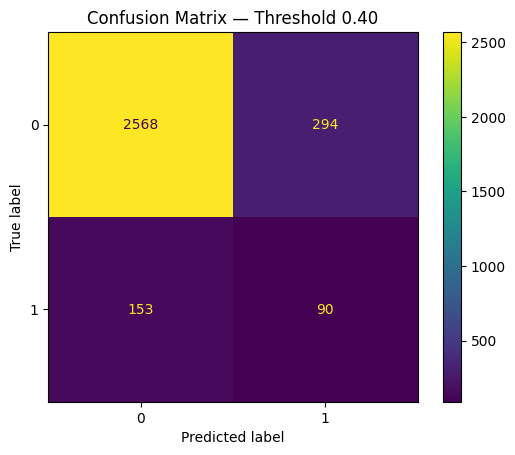

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()
plt.title(f"Confusion Matrix — Threshold {BEST_THRESHOLD:.2f}")
plt.show()

## 16. Precision-Recall curve

PR-AUC is especially useful here because the positive class is only around 8%.

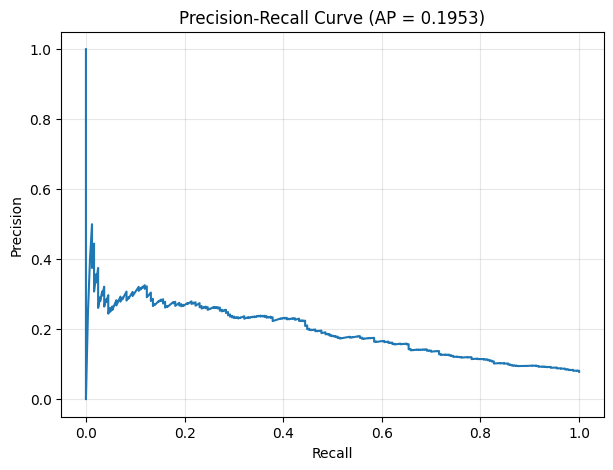

In [22]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {test_pr_auc:.4f})")
plt.grid(alpha=0.3)
plt.show()

## 17. Feature importance

For a pipeline containing OneHotEncoder, we retrieve the transformed feature names and pair them with LightGBM's feature importances.

In [23]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]
fitted_model = model_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

importances = fitted_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Number of transformed features:", len(feature_importance))

display(feature_importance.head(20))

Number of transformed features: 282


,feature,importance
8,num__DAYS_REGISTRATION,924
9,num__DAYS_ID_PUBLISH,898
29,num__EXT_SOURCE_3,851
77,num__DAYS_LAST_PHONE_CHANGE,844
28,num__EXT_SOURCE_2,790
106,num__ANNUITY_INCOME_RATIO,707
5,num__REGION_POPULATION_RELATIVE,697
3,num__AMT_ANNUITY,652
105,num__INCOME_PER_PERSON,650
27,num__EXT_SOURCE_1,575


## 18. Final model summary

In [24]:
summary = pd.DataFrame({
    "Metric": [
        "Train rows",
        "Validation rows",
        "Test rows",
        "Original features",
        "Transformed features",
        "Positive class % (train)",
        "scale_pos_weight",
        "Validation ROC-AUC",
        "Validation PR-AUC",
        "Selected threshold",
        "Test ROC-AUC",
        "Test PR-AUC"
    ],
    "Value": [
        len(X_train),
        len(X_val),
        len(X_test),
        X_train.shape[1],
        len(feature_importance),
        round(y_train.mean() * 100, 2),
        round(scale_pos_weight, 4),
        round(val_roc_auc, 4),
        round(val_pr_auc, 4),
        BEST_THRESHOLD,
        round(test_roc_auc, 4),
        round(test_pr_auc, 4)
    ]
})

display(summary)

,Metric,Value
0,Train rows,9934.0000
1,Validation rows,2484.0000
2,Test rows,3105.0000
3,Original features,171.0000
4,Transformed features,282.0000
5,Positive class % (train),7.8400
6,scale_pos_weight,11.7522
7,Validation ROC-AUC,0.6993
8,Validation PR-AUC,0.1699
9,Selected threshold,0.4000


## 19. Save the complete pipeline

The saved object includes:

- missing-value preprocessing
- OneHotEncoder
- LightGBM model

This prevents the training/prediction preprocessing mismatch that caused the previous feature-name warning.

During inference, pass a pandas DataFrame containing the original feature columns expected by the pipeline.

In [26]:
MODEL_PATH = "loan_lightgbm_pipeline.joblib"

joblib.dump(
    {
        "pipeline": model_pipeline,
        "threshold": BEST_THRESHOLD,
        "feature_columns": X_train.columns.tolist()
    },
    MODEL_PATH
)

print("Saved:", MODEL_PATH)

Saved: loan_lightgbm_pipeline.joblib
